In [ ]:
!pip install formulaic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00


In [ ]:
!pip install gapminder

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from formulaic import Formula

# Herramientas de modelos lineales
from sklearn import linear_model

# Medidas de desempeño
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# Regresión Polinomial

### Laboratorio de Datos, IC - FCEN - UBA - Verano 2026

Buscamos los coeficientes de un polinomio de grado $n$
$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \dots + \beta_n X^n$$

que mejor aproxime a nuestros datos en el sentido de Cuadrados Mínimos. Es decir, buscamos $\beta_1,\dots, \beta_n$ que minimicen:
$$ RSS(\beta) = \displaystyle\sum_{i=1}^n (y_i - P(x_i))^2 $$

Vamos a usar como ejemplo los datos de PBI per capita de Argentina, del dataset `gapminder`

In [ ]:
from gapminder import gapminder
datos_arg = gapminder[gapminder['country'] == 'Argentina'].reset_index(drop=True)
datos_arg

,country,continent,year,lifeExp,pop,gdpPercap
0,Argentina,Americas,1952,62.485,17876956,5911.315053
1,Argentina,Americas,1957,64.399,19610538,6856.856212
2,Argentina,Americas,1962,65.142,21283783,7133.166023
3,Argentina,Americas,1967,65.634,22934225,8052.953021
4,Argentina,Americas,1972,67.065,24779799,9443.038526
5,Argentina,Americas,1977,68.481,26983828,10079.026740
6,Argentina,Americas,1982,69.942,29341374,8997.897412
7,Argentina,Americas,1987,70.774,31620918,9139.671389
8,Argentina,Americas,1992,71.868,33958947,9308.418710
9,Argentina,Americas,1997,73.275,36203463,10967.281950


### Visualización

Teníamos la visualización de la Regresión Lineal:

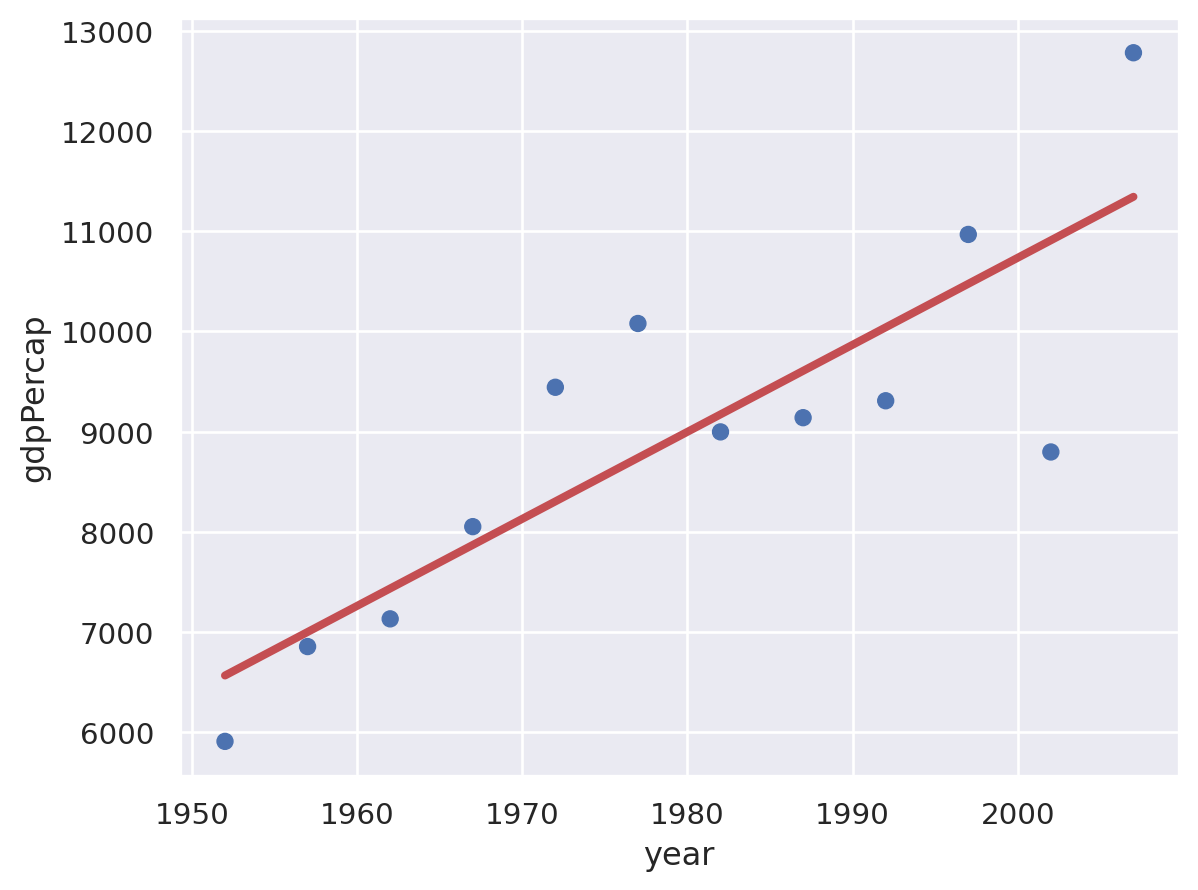

In [ ]:
(
    so.Plot(data=datos_arg, x='year', y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='r', linewidth=3), so.PolyFit(1))
)

Calculemos el $R^2$ de la Regresión Lineal:

In [ ]:
# Escribimos la fórmula
y = datos_arg["gdpPercap"]
X = datos_arg[["year"]]

# Inicializamos el modelo de regresión
modelo = linear_model.LinearRegression(fit_intercept=True)  # El default es True, pero lo podemos poner igual

# Realizamos el ajuste
modelo.fit(X, y)

# Calculamos R²
r2_score(y, modelo.predict(X)) #modelo.score(X, y)

0.7060056670920886

In [ ]:
modelo.coef_

array([86.81166447])

Para cambiar el grado del polinomio que ajusta los datos en Seaborn, simplemente cambios el argumento de `so.PolyFit`. Por ejemplo, para un polinomio de grado $3$:

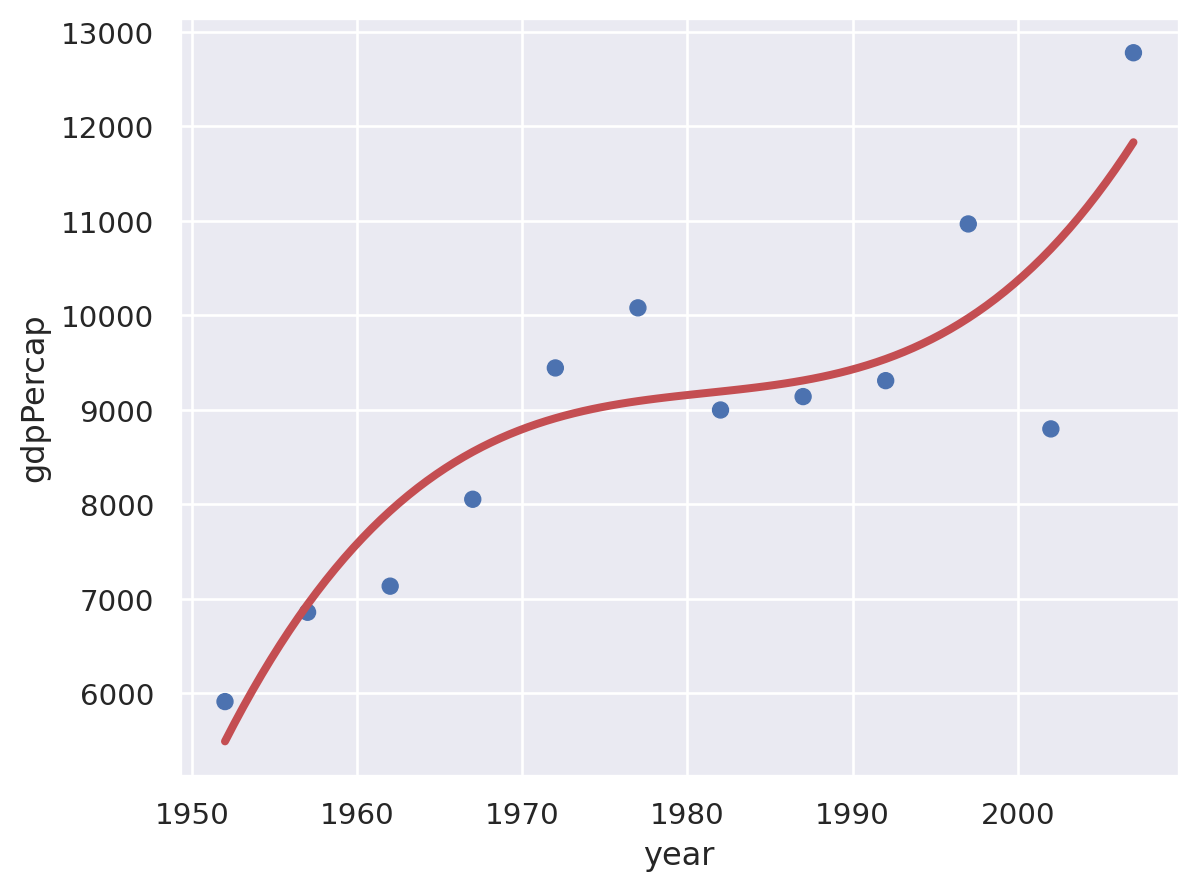

In [ ]:
(
    so.Plot(data=datos_arg, x=datos_arg['year'], y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='r', linewidth=3), so.PolyFit(3))
)

### Cálculo de coeficientes y de predicciones

Queremos buscar el polinomio de grado 3 que mejor aproxima a los datos en sentido de cuadrados mínimos:
$$P(x) = \beta_0 + \beta_1 x + \beta_2 x^ 2 + \beta_3 x^ 3$$

Calcularemos los coeficientes con `scikit-learn`. Es parecido a lo que hacíamos con la regresión lineal, pero con un paso extra: tenemos que construir la matriz de datos agregando columnas para $x^2$ y $x^3$.

### Formulaic: implementación de alto rendimiento de las fórmulas de Wilkinson para Python.

Aunque perfectamente podemos hacer la matriz "a mano", el paquete Formulaic nos permite hacerla automáticamente para polinomios de cualquier grado.

In [ ]:
# poly(year,3) significa que usamos un polinomio de grado 3 cuya variable es year
# raw = True nos da los datos "crudos", es decir genera columnas x, x^2 y x^3 sin ninguna transformación ni normalización.
# -1 significa que no queremos una columna de 1's en la matriz para el intercept

y, X = Formula('gdpPercap ~ poly(year, 3, raw=True) - 1').get_model_matrix(datos_arg)
y = y.iloc[:, 0]  # Convertimos el DataFrame a Series

In [ ]:
X

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1952,3810304,7437713408
1,1957,3829849,7495014493
2,1962,3849444,7552609128
3,1967,3869089,7610498063
4,1972,3888784,7668682048
5,1977,3908529,7727161833
6,1982,3928324,7785938168
7,1987,3948169,7845011803
8,1992,3968064,7904383488
9,1997,3988009,7964053973


In [ ]:
y

,gdpPercap
0,5911.315053
1,6856.856212
2,7133.166023
3,8052.953021
4,9443.038526
5,10079.026740
6,8997.897412
7,9139.671389
8,9308.418710
9,10967.281950


In [ ]:
# Inicializamos el modelo de regresión.
modelo = linear_model.LinearRegression(fit_intercept=True)

# Realiza el ajuste
modelo.fit(X, y)

# Como usamos fit_intercept = True, la ordenada al origen está en modelo.intercept_
ordenada_al_origen = modelo.intercept_

# Recuperamos los valores de los demas coeficientes (de menor potencia a la mayor)
coeficientes = modelo.coef_

# Armamos el array con los valores de beta
beta = np.array([ordenada_al_origen, *coeficientes])

# Imprimimos los valores:
print('beta_0: ', beta[0])
print('beta_1: ', beta[1])
print('beta_2: ', beta[2])
print('beta_3: ', beta[3])

beta_0:  -984937719.5828154
beta_1:  1491410.418860954
beta_2:  -752.7757907716605
beta_3:  0.12665380167231888


El polinomio de grado a lo sumo 3 que mejor aproxima a los datos es:
$$P(x) = -984937719.58 + 1491410.41 x -752.77 x^ 2 + 0.12 x^ 3 $$

Corroboremos que el gráfico de este polinomio es el mismo que arma `seaborn` con `so.PolyFit`:

In [ ]:
X

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1952,3810304,7437713408
1,1957,3829849,7495014493
2,1962,3849444,7552609128
3,1967,3869089,7610498063
4,1972,3888784,7668682048
5,1977,3908529,7727161833
6,1982,3928324,7785938168
7,1987,3948169,7845011803
8,1992,3968064,7904383488
9,1997,3988009,7964053973


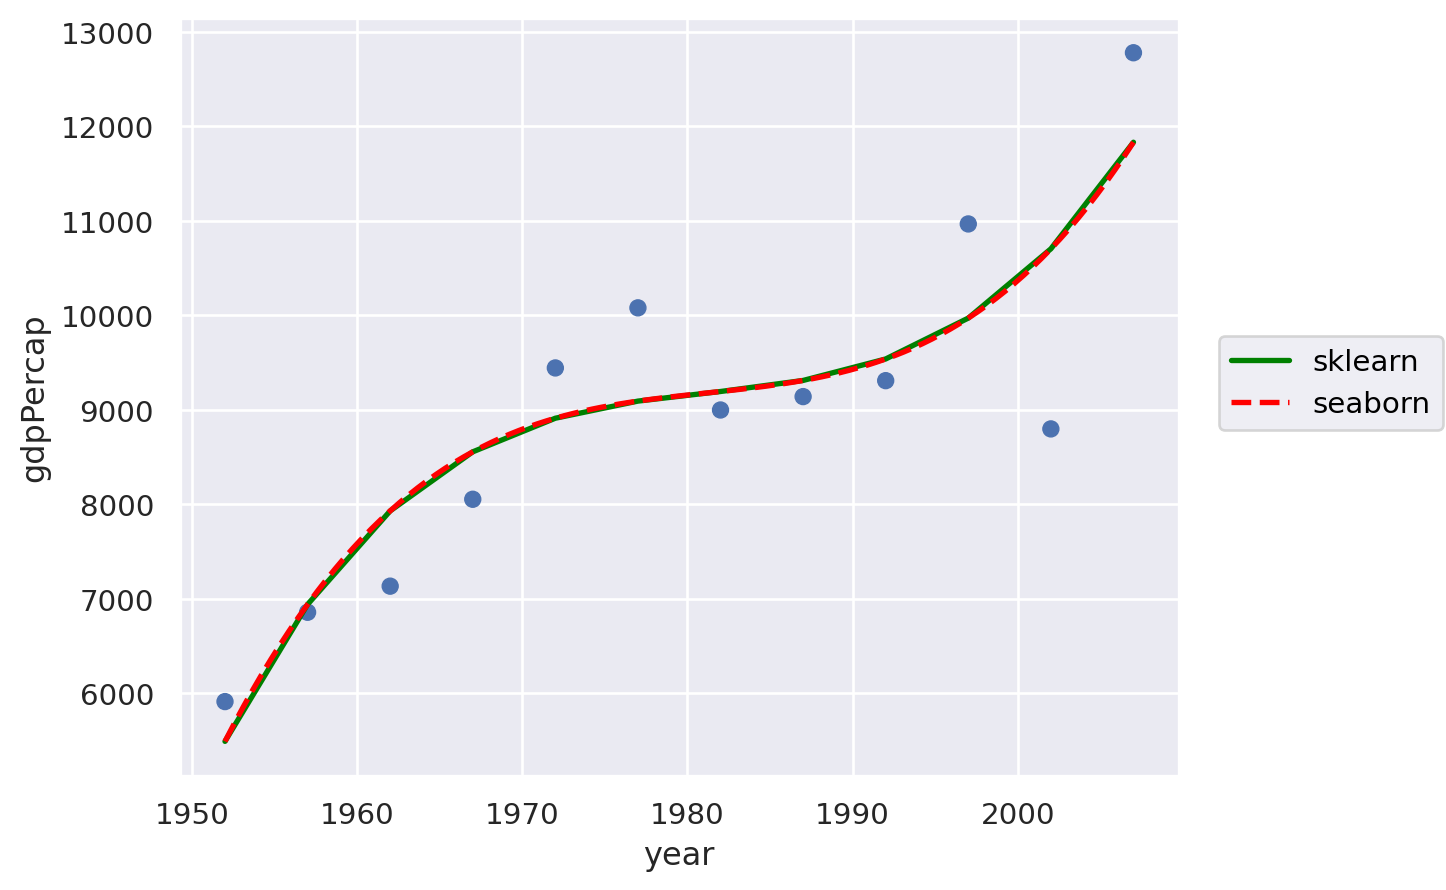

In [ ]:
(
    so.Plot(data=datos_arg, x='year', y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='green', linewidth=2), y=modelo.predict(X), label='sklearn')
    .add(so.Line(color='red', linestyle='--', linewidth=2), so.PolyFit(3), label='seaborn')
    .label()
)

Igual que antes, podemos estimar el PBI per capita, por ejemplo para 1990 y 2015:

* haciendo las cuentas

In [ ]:
# Haciendo las cuentas a mano
prediccion_1990 = beta @ 1990**np.arange(4, dtype='int64')

# O usando numpy
prediccion_2015 = beta @ 2015**np.arange(4, dtype='int64')

print('Prediccion 1990: ', prediccion_1990)
print('Prediccion 2015: ', prediccion_2015)

Prediccion 1990:  9427.720705032349
Prediccion 2015:  14697.104548573494


* usando `predict`

In [ ]:
# Armamos un DataFrame con los datos de x a los cuales les queremos aplicar el modelo
nuevos = pd.DataFrame({"year":  [1990, 2015]})

# Armamos el DataFrame para pasarle a predict
datos_a_predecir = Formula('gdpPercap ~ poly(year, 3, raw=True) - 1').rhs.get_model_matrix(nuevos)   #rhs (right hand side) nos da solo x
datos_a_predecir

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1990,3960100,7880599000
1,2015,4060225,8181353375


In [ ]:
modelo.predict(datos_a_predecir)

array([ 9427.72070503, 14697.10454857])

También podemos calcular las medidas de desempeño del modelo:

In [ ]:
y_pred = modelo.predict(X)

# Calculando el R^2
r2 = r2_score(datos_arg['gdpPercap'], y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('ECM: ', ecm)

# Calculando la RECM
recm = root_mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('RECM: ', recm)

R^2:  0.7910974741508592
ECM:  664333.9855668667
RECM:  815.0668595685061


## Ejercicio

En el dataset mpg queremos realizar un modelo para estimar la eficiencia (mpg) en función de los caballos de fuerza.

1. Graficar mpg en función de los caballos de fuerza.
2. Si quemos realizar regresión polinomial, ¿qué grado parece adecuado?
3. Agregar en el gráfico el ajuste polinomial so.PolyFit() con el grado propuesto. Resultó apropiado el grado?
4. Estimar los parámetros $\beta$ del ajuste y calcular el $R^2$.
5. Eligiendo otros pares de variables, encuentra alguno en el que regresión polinomial parezca más apropiada que regresión lineal?

In [ ]:
mpg = sns.load_dataset('mpg')
mpg = mpg.dropna(subset=["horsepower", "weight", "mpg"])  # Eliminamos filas con datos faltantes

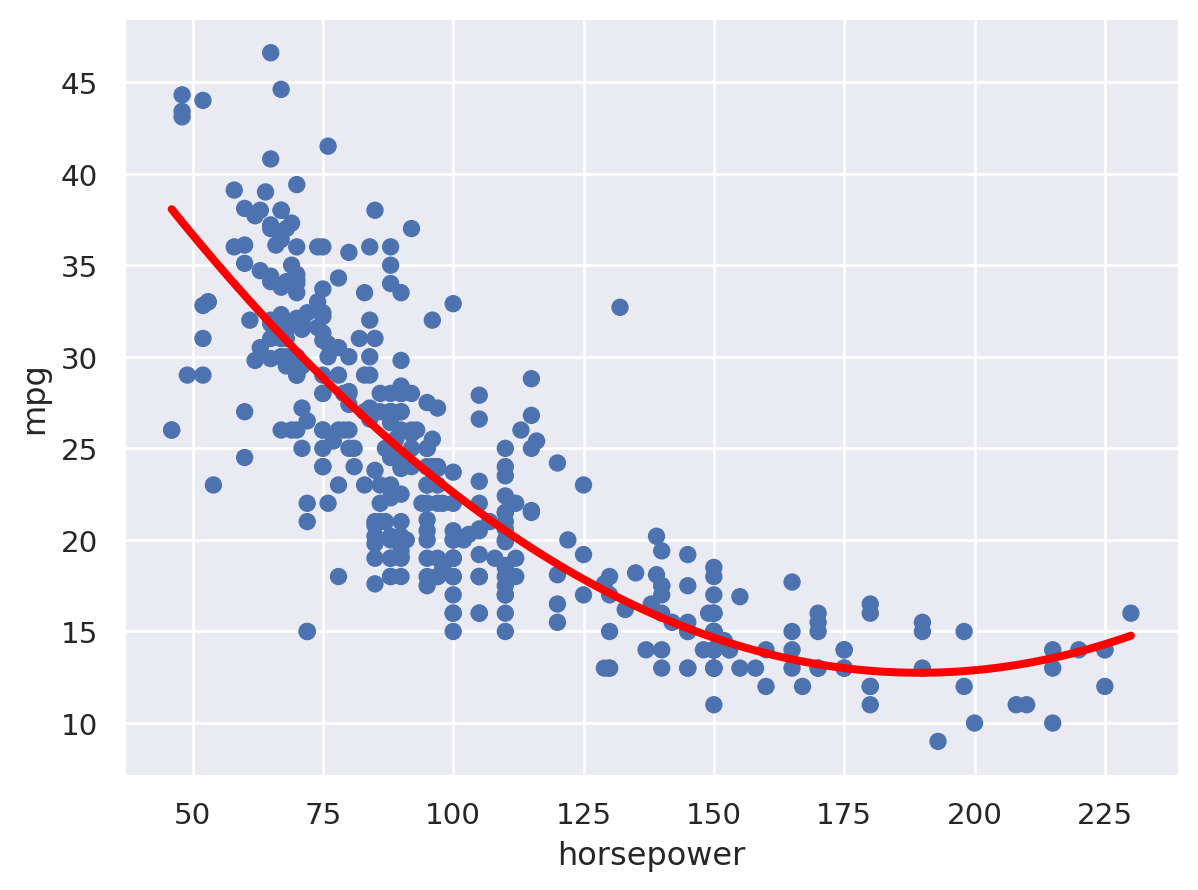

In [ ]:
(
    so.Plot(data=mpg, x='horsepower', y='mpg')
    .add(so.Dot())
    .add(so.Line(color = 'red', linewidth = 3.0), so.PolyFit(2))
)

In [ ]:
y_mpg, X_mpg = Formula('mpg ~ poly(horsepower, 2, raw = True) - 1').get_model_matrix(mpg)
y_mpg = y_mpg.iloc[:, 0]

In [ ]:
X_mpg

,"poly(horsepower, 3, raw=True)[0]","poly(horsepower, 3, raw=True)[1]","poly(horsepower, 3, raw=True)[2]"
0,130.0,16900.0,2197000.0
1,165.0,27225.0,4492125.0
2,150.0,22500.0,3375000.0
3,150.0,22500.0,3375000.0
4,140.0,19600.0,2744000.0
...,...,...,...
393,86.0,7396.0,636056.0
394,52.0,2704.0,140608.0
395,84.0,7056.0,592704.0
396,79.0,6241.0,493039.0


In [ ]:
y_mpg

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [ ]:
model_mpg = linear_model.LinearRegression(fit_intercept = True)
model_mpg.fit(X_mpg, y_mpg)

LinearRegression()

In [ ]:
model_mpg.intercept_

np.float64(56.90009970211294)

In [ ]:
model_mpg.coef_

array([-0.46618963,  0.00123054])

In [ ]:
model_mpg.score(X_mpg, y_mpg)

0.6875590305127516

In [ ]:
mpg["predict"] = model_mpg.predict(X_mpg)

In [ ]:
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,predict
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,17.091508
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,13.480156
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,14.658717
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,14.658717
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,15.752059
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,25.908837
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,35.985609
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,26.422834
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,27.750895


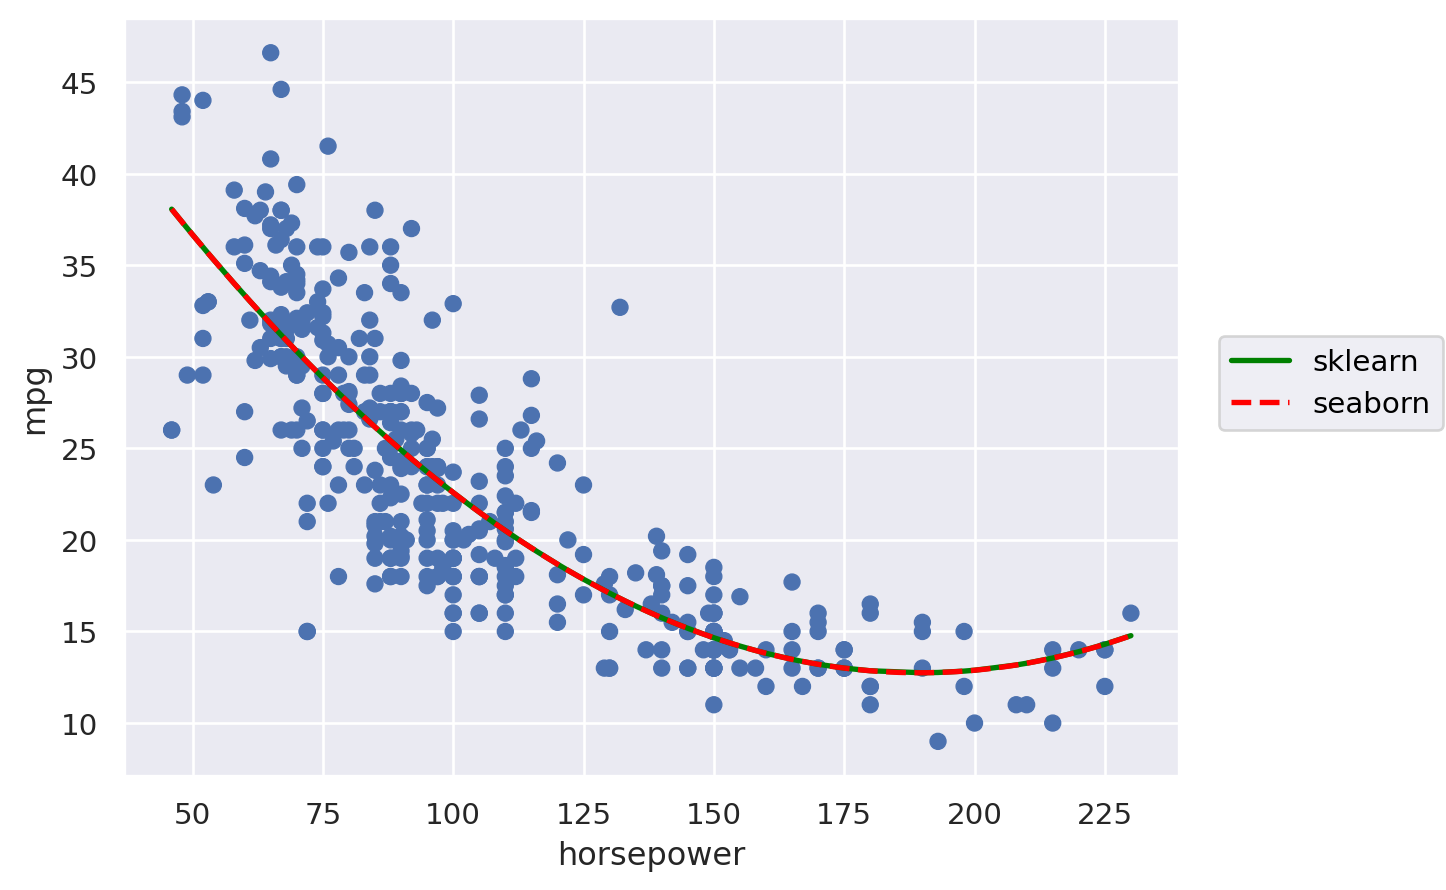

In [ ]:
(
    so.Plot(data=mpg, x='horsepower', y='mpg')
    .add(so.Dot())
    .add(so.Line(color='green', linewidth=2), y="predict", label='sklearn')
    .add(so.Line(color='red', linestyle='--', linewidth=2), so.PolyFit(2), label='seaborn')
    .label()
)

## Regresión con funciones bases

Vamos a trabajar con mediciones de dióxido de carbono en el aire en el observatorio de Mauna Loa (Hawaii)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargamos los datos y graficamos
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lic_CsdeDatos/LaboDatos/co2_hawaii.csv')
data

,fecha,co2
0,1958-03-31,316.100000
1,1958-04-30,317.200000
2,1958-05-31,317.433333
3,1958-07-31,315.625000
4,1958-08-31,314.950000
...,...,...
516,2001-08-31,369.425000
517,2001-09-30,367.880000
518,2001-10-31,368.050000
519,2001-11-30,369.375000


In [ ]:
# Tomamos la fecha como indice
data = data.set_index("fecha")
data

,co2
fecha,
1958-03-31,316.100000
1958-04-30,317.200000
1958-05-31,317.433333
1958-07-31,315.625000
1958-08-31,314.950000
...,...
2001-08-31,369.425000
2001-09-30,367.880000
2001-10-31,368.050000


In [ ]:
type(data)

pandas.core.frame.DataFrame

<Axes: xlabel='fecha'>

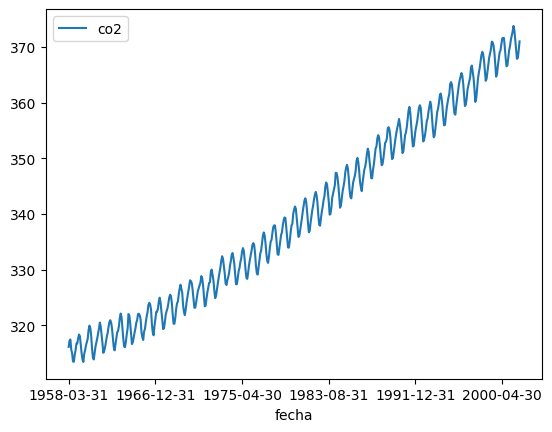

In [ ]:
# Graficamos
data.plot()

Queremos ajustar a los datos una función de la forma
$$
co2 = \beta_0 + \beta_1 * mes + \beta_2 * \sin\left(2 \pi *  \frac{mes}{12}\right)
$$

Construimos una matriz $X$ con una columna para el mes y otra columna para el seno.

In [ ]:
# ¿Cuántos meses hay en los datos?
data.co2.size

521

In [ ]:
mes = np.arange(521)
X = pd.DataFrame(
    {
        "mes": mes,
        "mes2": mes**2,
        #"mes3": mes**3,
        "sinx": np.sin(2*np.pi*mes/12),
        "cosx": np.cos(2*np.pi*mes/12)
        #"sin13x": np.sin(2*np.pi*mes/13),
        #"cos13x": np.cos(2*np.pi*mes/13)
    },
    index=data.index
)
X

,mes,mes2,sinx,cosx
fecha,,,,
1958-03-31,0,0,0.000000e+00,1.000000e+00
1958-04-30,1,1,5.000000e-01,8.660254e-01
1958-05-31,2,4,8.660254e-01,5.000000e-01
1958-07-31,3,9,1.000000e+00,6.123234e-17
1958-08-31,4,16,8.660254e-01,-5.000000e-01
...,...,...,...,...
2001-08-31,516,266256,-1.763739e-14,1.000000e+00
2001-09-30,517,267289,5.000000e-01,8.660254e-01
2001-10-31,518,268324,8.660254e-01,5.000000e-01


In [ ]:
# Variable respuesta
y = data["co2"]
y

,co2
fecha,
1958-03-31,316.100000
1958-04-30,317.200000
1958-05-31,317.433333
1958-07-31,315.625000
1958-08-31,314.950000
...,...
2001-08-31,369.425000
2001-09-30,367.880000
2001-10-31,368.050000


In [ ]:
# Ajustamos el modelo
modeloCO2 = linear_model.LinearRegression(fit_intercept=True)
modeloCO2.fit(X, y)

LinearRegression()

In [ ]:
modeloCO2.intercept_

np.float64(314.3796164292933)

In [ ]:
modeloCO2.coef_

array([ 6.97806037e-02,  8.10993025e-05, -2.31628559e+00, -6.47340970e-01])

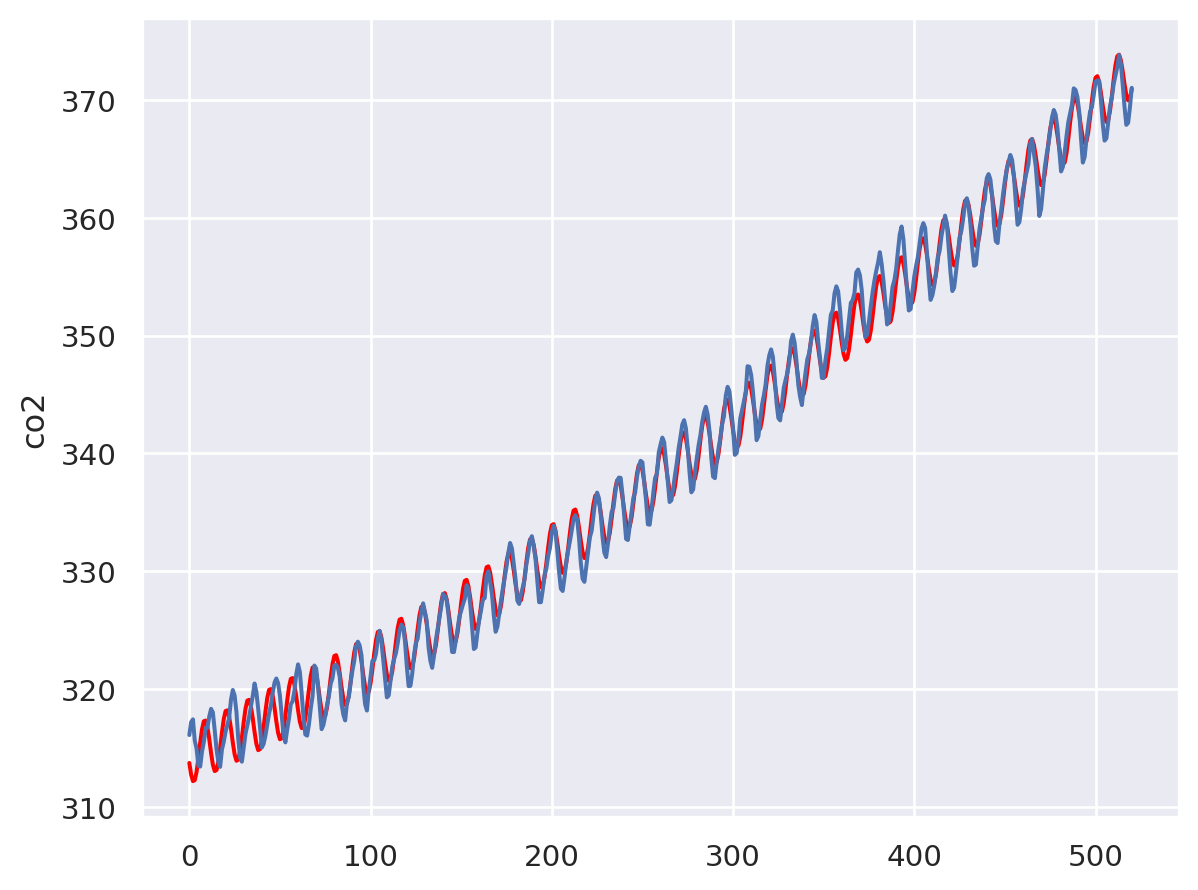

In [ ]:
# Predecimos
y_pred = modeloCO2.predict(X)
data["pred"] = y_pred  # Agregamos las predicciones al dataframe de datos para que sea más fácil graficar
(
    so.Plot(data, x = mes, y = "co2")  # Podemos usar también x = data.index pero no se ve bien
    .add(so.Line(color = "red"), y = "pred")
    .add(so.Line())
)

In [ ]:
# Calculamos el R^2
modeloCO2.score(X,y)

0.9939902971564184

## Residuos
El $R^2$ nos dio muy bien! Se podrá mejorar?
Veamos los residuos...

In [ ]:
data["res"][:20]

,res
fecha,
1958-03-31,2.192543
1958-04-30,4.427021
1958-05-31,5.342003
1958-07-31,3.566834
1958-08-31,2.253814
1958-09-30,-0.350188
1958-11-30,-1.804372
1958-12-31,-1.785359
1959-01-31,-1.805036


<Axes: xlabel='fecha'>

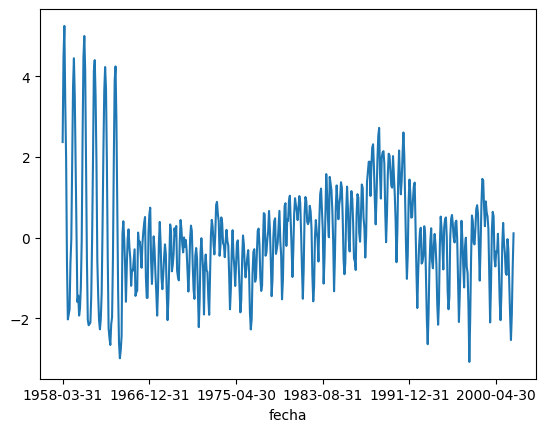

In [ ]:
data["res"] = data["co2"] - data["pred"]
data.res.plot()

Los residuos no parecen al azar... ¡podemos mejorar el ajuste!

## Ejercicio

Agregar otras funciones base al modelo y ver si mejora el ajuste en el gráfico y el $R^2$.

Recordar que solo podemos usar una combinación lineal de funciones base.

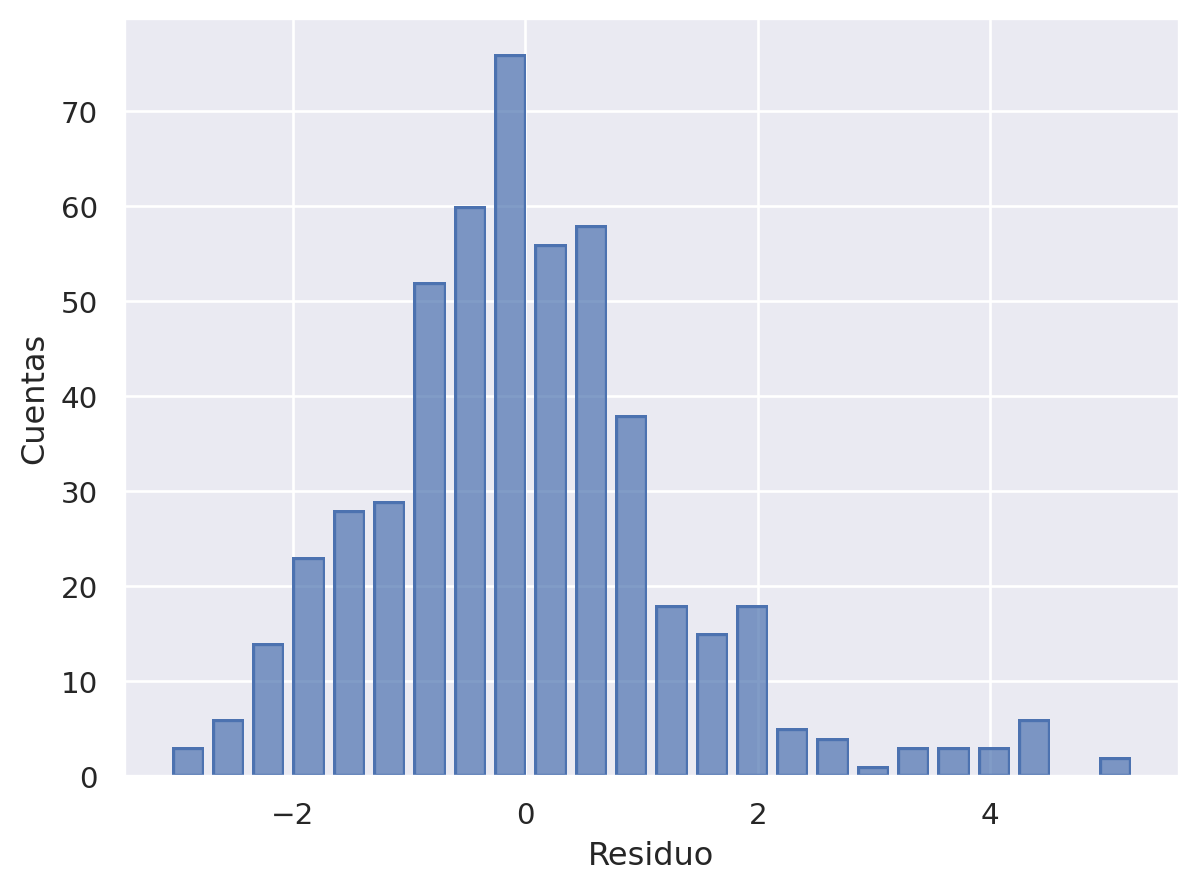

In [ ]:
(
    so.Plot(data = data, x = "res")
    .add(so.Bar(), so.Hist())
    .label(x = "Residuo", y = "Cuentas")
)